In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import pandas as pd

In [2]:
data_1 = pd.Series([1, 9, 1, 5, 5, 2, 2, 8, 3, 7, 1])
data_2 = pd.Series([1, 9, 1, 5, 5, 2, 2, 8, 3, 7, 25])

In [149]:
# Get data for use in Figures 1 and 7
cellex_url = r"https://raw.githubusercontent.com/jimlehner/The-Math-Matters/refs/heads/main/measures-of-dispersion/data/cellex-cell-voltage.csv"

# Get data function
def get_data(dataset_url) -> pd.DataFrame:
    return pd.read_csv(dataset_url)

# Get the data
cellex_df = get_data(cellex_url)

cellex_df.head()

,Supplier,Sample,Cell Voltage (mV)
0,Cellex,1,642.768
1,Cellex,2,657.319
2,Cellex,3,664.052
3,Cellex,4,658.694
4,Cellex,5,642.644


## Figure 1.
XmR chart of cell voltages 

In [189]:
round_value = 3
# Get the voltage data
voltage = cellex_df["Cell Voltage (mV)"]
# Calculate the moving range
voltage_mR = round(abs(voltage.diff()),3)

# Calculate process statistics
voltage_mean = round(voltage.mean(), round_value)
voltage_ave_mR = round(voltage_mR.mean(), round_value)

# Calculate process limits
voltage_UPL = round(voltage_mean + (2.660*voltage_ave_mR),3)
voltage_LPL = round(voltage_mean - (2.660*voltage_ave_mR),3)
voltage_URL = round(3.268*voltage_ave_mR, 3)

xchart_list = [voltage_mean, voltage_UPL, voltage_LPL]
mrchart_list = [voltage_ave_mR, voltage_URL]

662.261
688.792
635.73


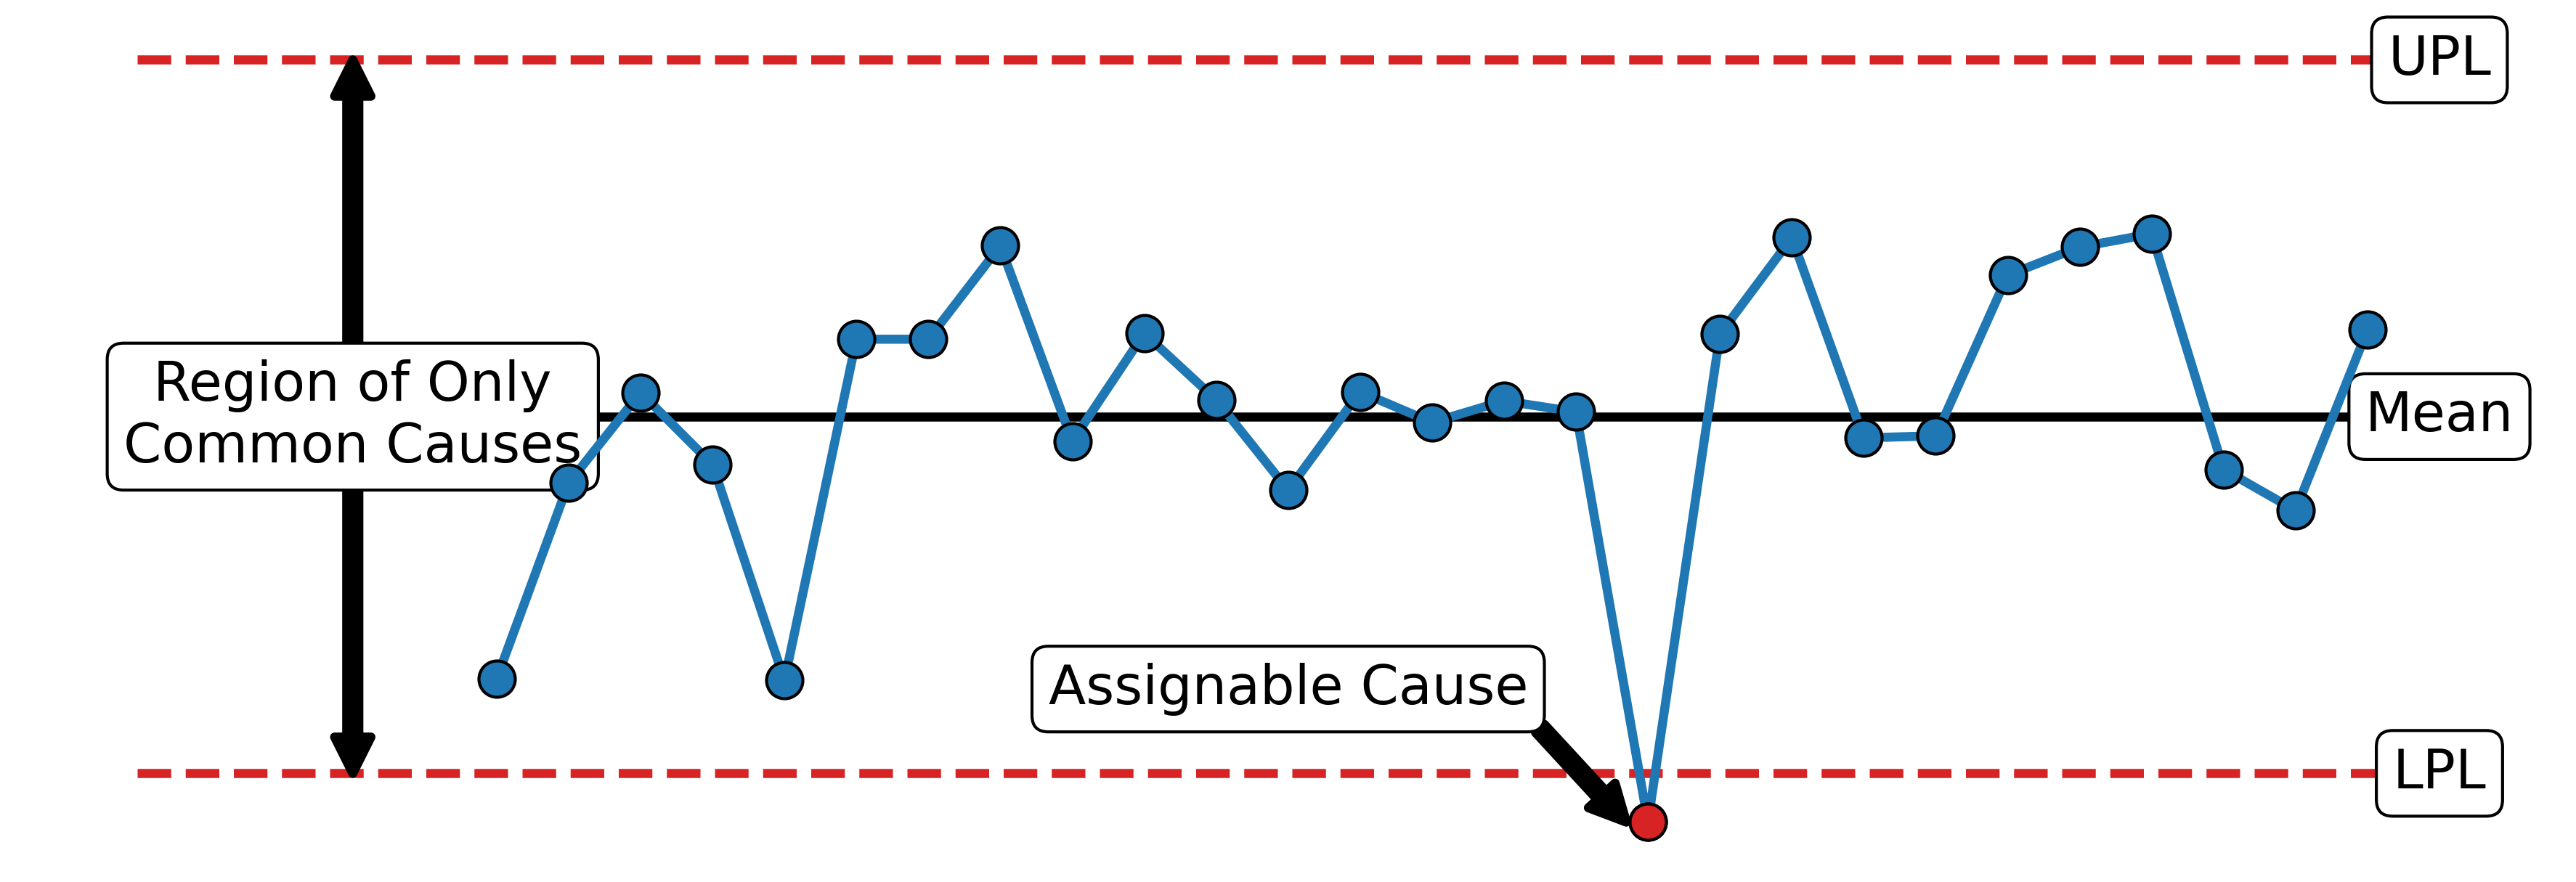

In [302]:
voltage = cellex_df["Cell Voltage (mV)"]

fig, ax = plt.subplots(
    figsize=(15,5),
    dpi=300)

# Plot Voltage Values
ax.plot(
        voltage,
        marker="o",
        markersize=12,
        markeredgecolor='black',
        linewidth=3, 
        zorder=4
    )

below_lpl = voltage < voltage_LPL
greater_url = voltage_mR > voltage_URL

# Highlight values less than the Lower Process Limit (LPL)
ax.plot(
        voltage[below_lpl],
        marker="o",
        markersize=12,
        markeredgecolor="black",
        markerfacecolor="#d72323",
        linestyle="none",
        zorder=5
    )

# Calculate length of voltage
x_end = len(voltage)
x_start = -5

for i, xchart_limit in enumerate(xchart_list):
    ax.hlines(
        y=xchart_limit,
        xmin=x_start,
        xmax=x_end,
        color="black" if i == 0 else "#d72323",
        ls="-" if i == 0 else "--",
        linewidth=3
    )

# Annotations
annotations = [
    ("Assignable Cause", (15.7, 632.1), (11, 642)),
    ("Mean", (x_end, voltage_mean), (x_end, voltage_mean)),
    ("UPL", (x_end, voltage_UPL), (x_end, voltage_UPL)),
    ("LPL", (x_end, voltage_LPL), (x_end, voltage_LPL)),
    ("", (-2, voltage_UPL), (-2, voltage_mean)),
    ("", (-2, voltage_LPL), (-2, voltage_mean)),
    ("Region of Only\nCommon Causes", (0, voltage_mean), (-2, voltage_mean))
]

# Add annotations
for text, xy, xytext in annotations:
    ax.annotate(
        text,
        xy=xy,
        xytext=xytext,
        ha="center",
        va="center",
        fontsize=18,
        arrowprops=dict(
            color="black",
            lw=3
        ),
        bbox=dict(
            facecolor="white",
            edgecolor="black",
            boxstyle="round"
        )
    )
    
    
# Remove xticks
ax.set_xticks([])
ax.set_yticks([])

# Despne plots
sns.despine(left=True, bottom=True)
        
plt.show()

## Figure 3.
The range is calculated by subtracting the smallest value from the largest.

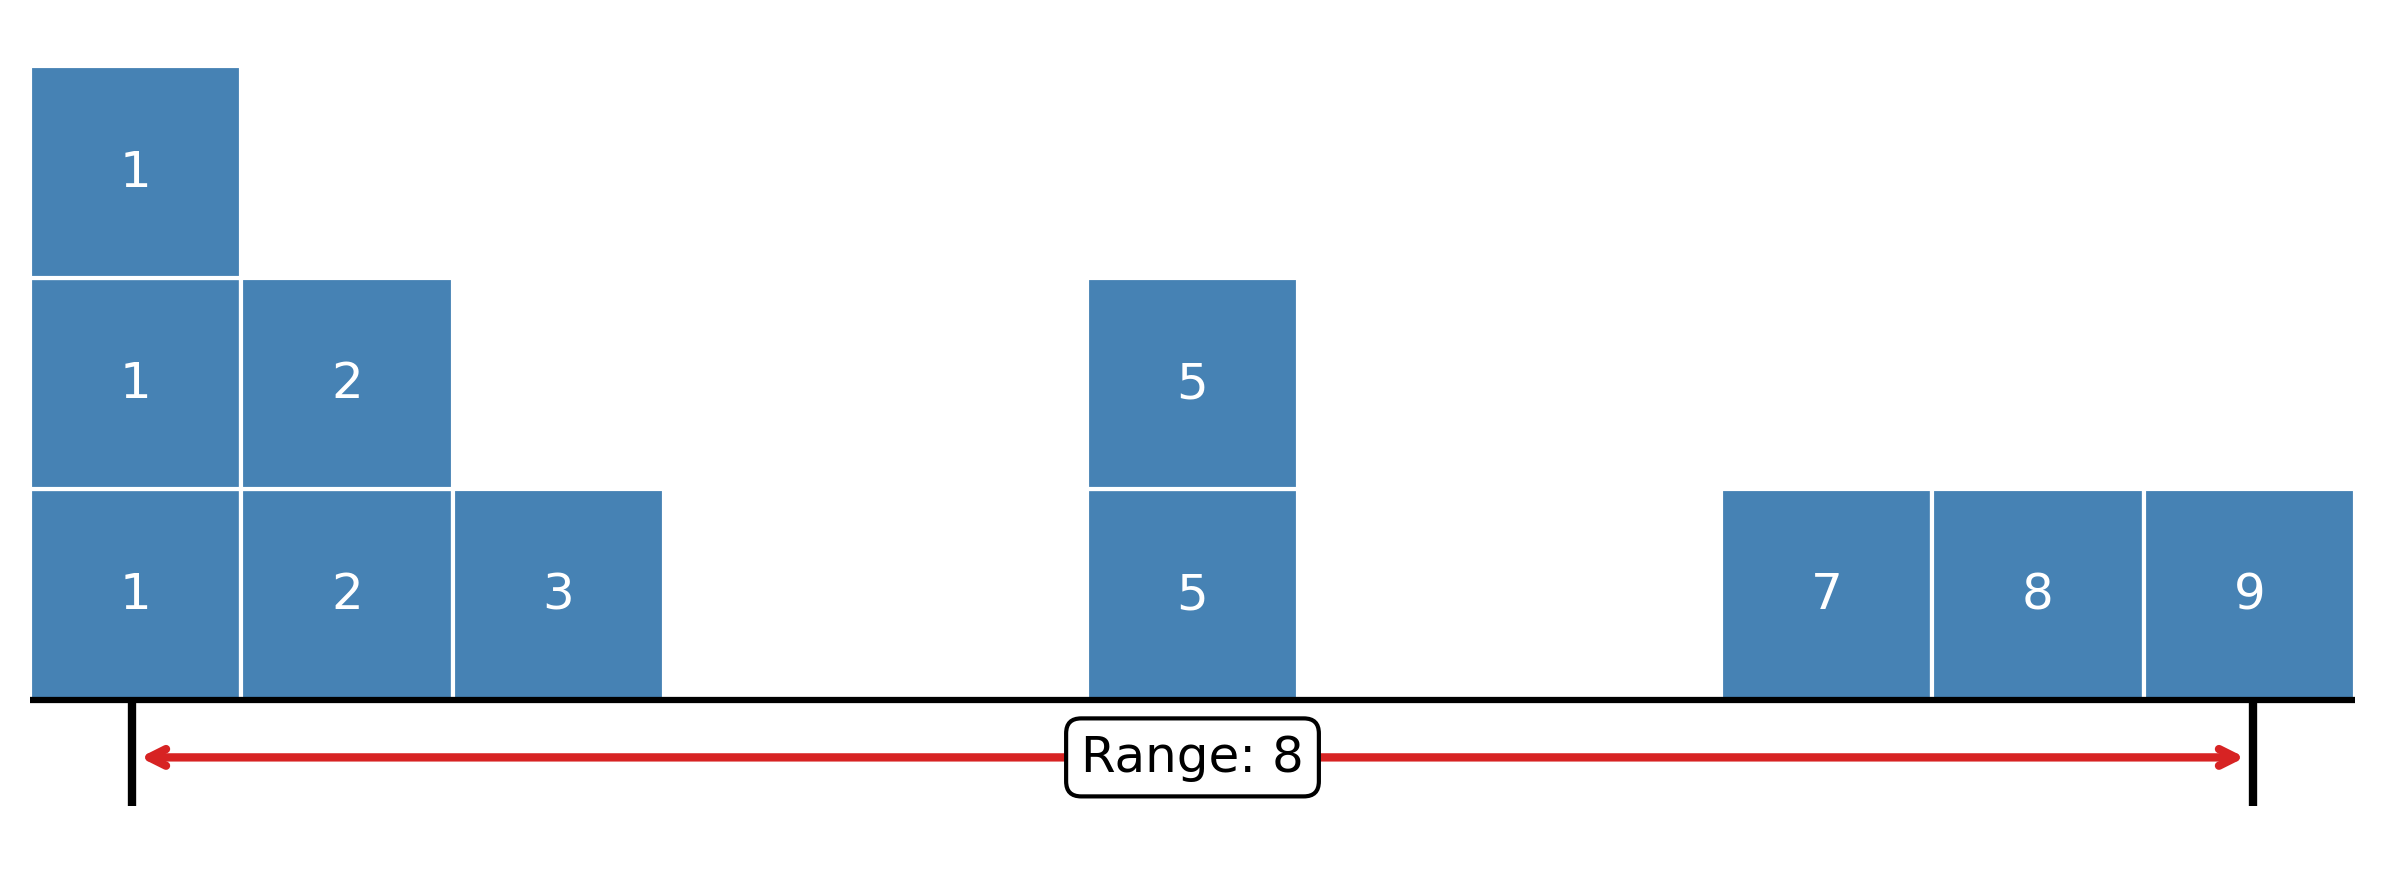

In [127]:
data_arr = np.asarray(data_1)
counts, bin_edges = np.histogram(data_arr, bins=11)
bin_width = bin_edges[1] - bin_edges[0]

# Create matplotlib figure
fig, ax = plt.subplots(figsize=(10, 5), dpi=300)
n_bins = len(bin_edges) - 1

for i in range(n_bins):
    left, right = bin_edges[i], bin_edges[i + 1]
    
    # Find the observations in the bin
    if i < n_bins - 1:
        in_bin = data_arr[(data_arr >= left) & (data_arr < right)]
    else:
        in_bin = data_arr[(data_arr >= left) & (data_arr <= right)]
    
    # Sort the observations
    in_bin_sorted = np.sort(in_bin)
    
    # Create squares for each observations
    for j, val in enumerate(in_bin_sorted):
        square = patches.Rectangle(
            (left, j), bin_width, 1,
            facecolor="steelblue", edgecolor="white"
        )
        ax.add_patch(square)
        
        # Add text to center of each square
        ax.text(
            left + bin_width / 2, j + 0.5, f"{val:g}",
            ha="center", va="center", color="white", fontsize=12
        )

# Set x-limits
ax.set_xlim(bin_edges[0], bin_edges[-1])

# Add range annotation
ax.text(
    5, -.27, "Range: 8",
    ha="center", 
    va="center",
    color="black", 
    fontsize=12,
    bbox=dict(facecolor="white",
             edgecolor="black",
             boxstyle="round")
           )

# Add double sided arrow
ax.annotate(
    "", xy=(1.35, -0.27), xytext=(8.65, -0.27),
    arrowprops=dict(arrowstyle="<->", lw=2, color="#d72323"),
    zorder=1
)

# Add horizontal line at zero
ax.axhline(0, color="black")

# Set aspect ratio to bin width
ax.set_aspect(bin_width)

# Despine plot
sns.despine(left=True, bottom=True)

# Lower range line
ax.vlines(8.65, ymin=-0.5, ymax=0, color="black", ls="-", lw=2)
# Upper range line
ax.vlines(1.35, ymin=-0.5, ymax=0, color="black", ls="-", lw=2)

# Remove x and y ticks
ax.set_yticks([])
ax.set_xticks([])

plt.show()

## Figure 5.
The second step in calculating the standard deviation is to determine the deviation of each value in the dataset from the target.

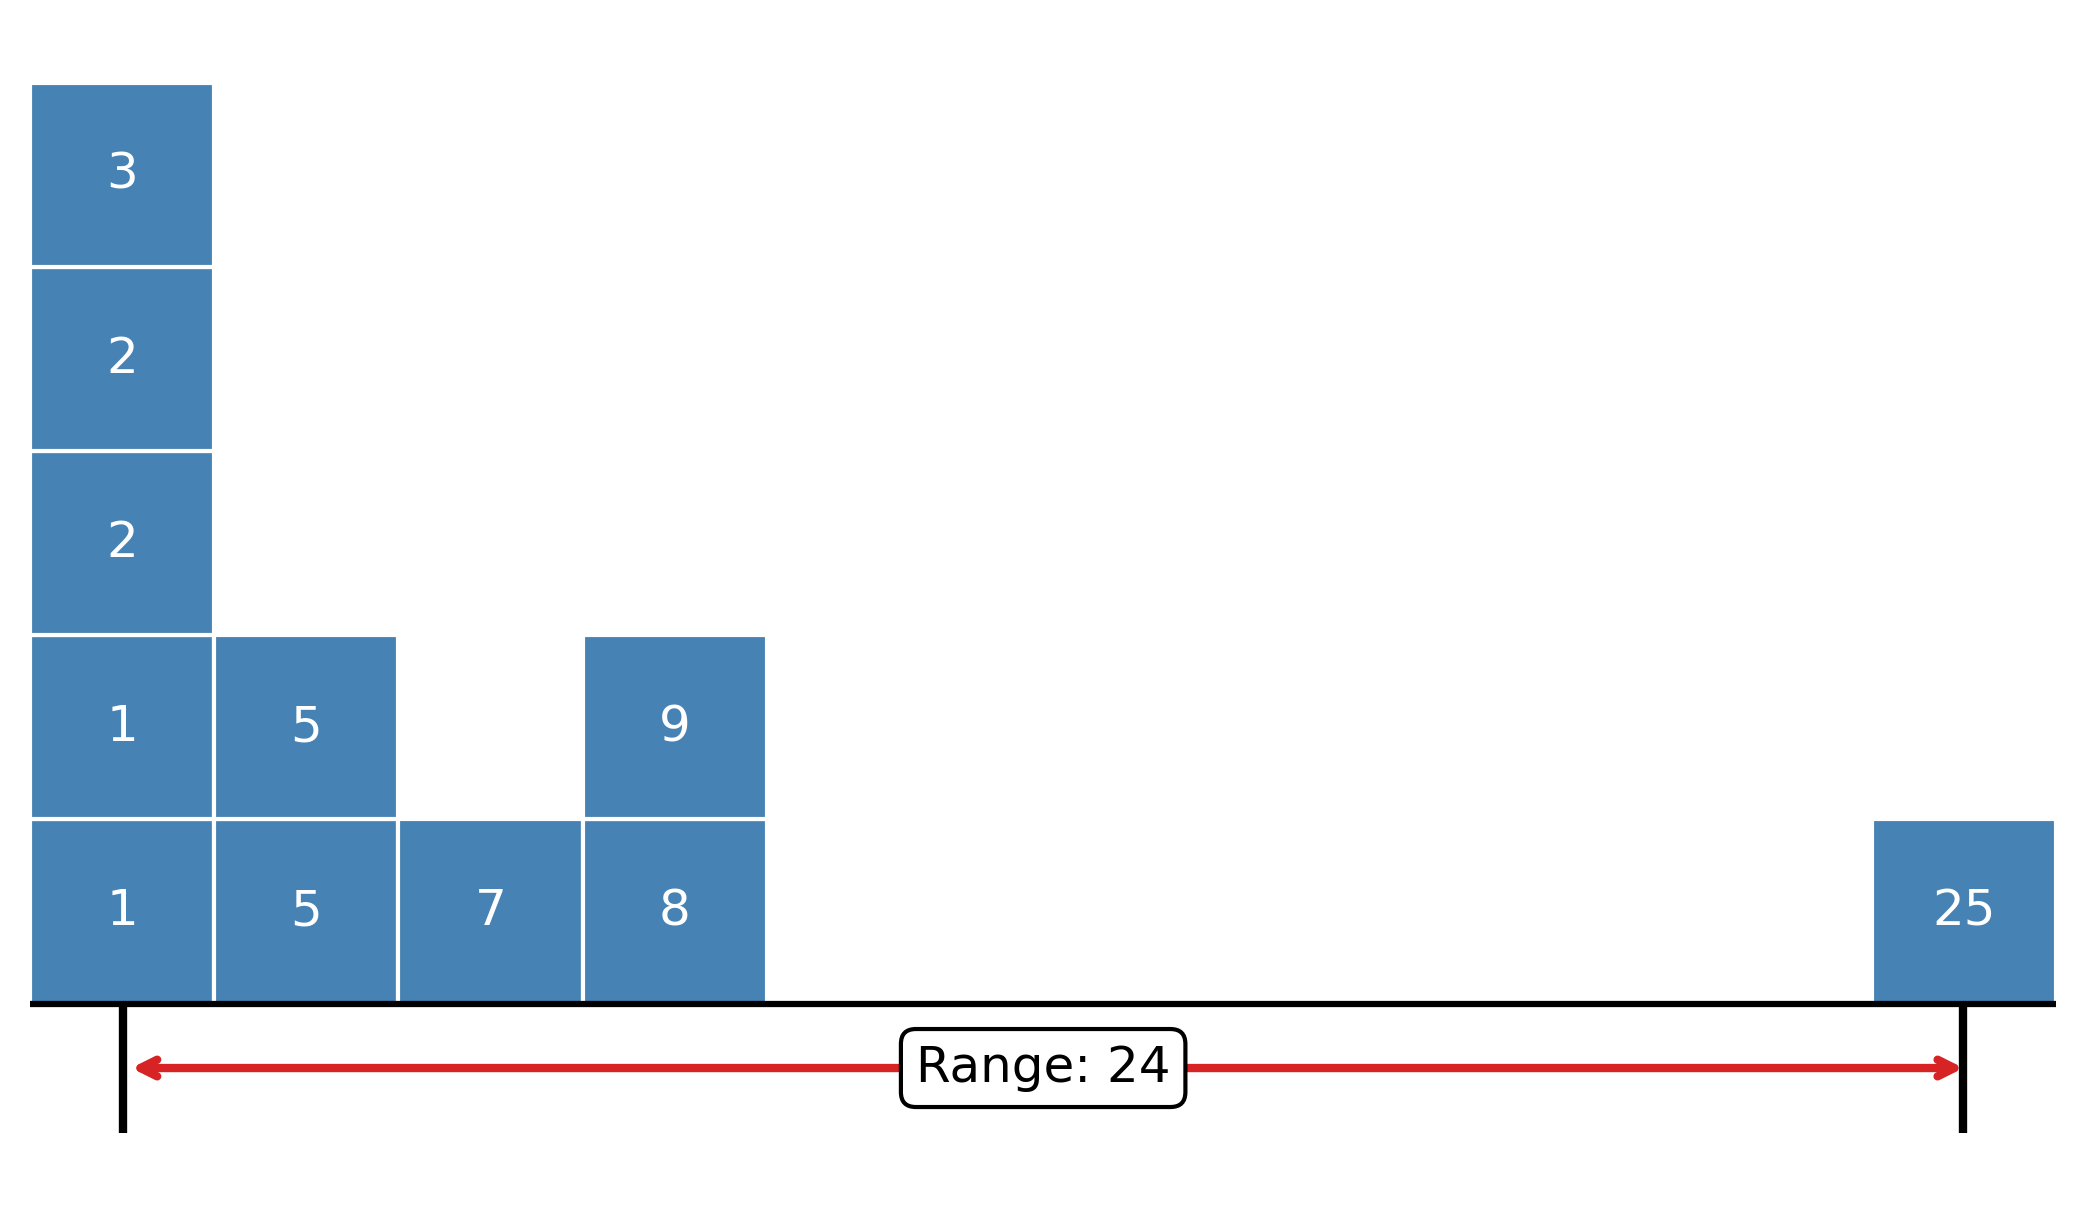

In [128]:
data_arr = np.asarray(data_2)
counts, bin_edges = np.histogram(data_arr, bins=11)
bin_width = bin_edges[1] - bin_edges[0]

# Create matplotlib figure
fig, ax = plt.subplots(figsize=(10, 5), dpi=300)
n_bins = len(bin_edges) - 1

for i in range(n_bins):
    left, right = bin_edges[i], bin_edges[i + 1]
    
    # Find the observations in the bin
    if i < n_bins - 1:
        in_bin = data_arr[(data_arr >= left) & (data_arr < right)]
    else:
        in_bin = data_arr[(data_arr >= left) & (data_arr <= right)]
    in_bin_sorted = np.sort(in_bin)
    
    # Create squares for each observations
    for j, val in enumerate(in_bin_sorted):
        square = patches.Rectangle(
            (left, j), bin_width, 1,
            facecolor="steelblue", edgecolor="white"
        )
        ax.add_patch(square)
        
        # Add text to center of each square
        ax.text(
            left + bin_width / 2, j + 0.5, f"{val:g}",
            ha="center", va="center", color="white", fontsize=12
        )

# Specify x axis limits
ax.set_xlim(bin_edges[0], bin_edges[-1])

# Add range annotation
ax.text(
    13, -.35, "Range: 24",
    ha="center", 
    va="center",
    color="black", 
    fontsize=12,
    bbox=dict(facecolor="white",
             edgecolor="black",
             boxstyle="round")
           )

# Add double headed arrow
ax.annotate(
    "", xy=(2.1, -0.35), xytext=(24, -0.35),
    arrowprops=dict(arrowstyle="<->", lw=2, color="#d72323"),
    zorder=1
)

# Add horizontal line at 0
ax.axhline(0, color="black")

# Set the aspect ratio to bin width
ax.set_aspect(bin_width)

# Despine the plot
sns.despine(left=True, bottom=True)

# Lower range black vertical line
ax.vlines(23.9, ymin=-0.7, ymax=0, color="black", ls="-", lw=2)
# Upper range black vertical line
ax.vlines(2.1, ymin=-0.7, ymax=0, color="black", ls="-", lw=2)

# Remove x and y ticks
ax.set_yticks([])
ax.set_xticks([])

plt.show()

## Figure 5.
The second step in calculating the standard deviation is to determine the deviation of each value in the dataset from the target.

In [129]:
# Specify values and locations for deviation labels
deviation_labels = [
    ("-3", 1.33, -0.25),
    ("-3", 1.33, -0.5),
    ("-3", 1.33, -0.75),
    ("-2", 2.06, -1),
    ("-2", 2.06, -1.25),
    ("-1", 2.8, -1.5),
    ("1", 5, -1.75),
    ("3", 7.21, -2),
    ("4", 7.93, -2.25),
    ("5", 8.69, -2.5)
]

# Specify lengths for the deviation arrows
deviation_arrow_groups = [
    (3.9, [
        (1.40, -0.25),
        (1.40, -0.5),
        (1.40, -0.75),
        (2.13, -1),
        (2.13, -1.25),
        (2.87, -1.5),
    ]),
    (4.1, [
        (4.93, -1.75),
        (7.14, -2),
        (7.86, -2.25),
        (8.62, -2.5),
    ]),
]

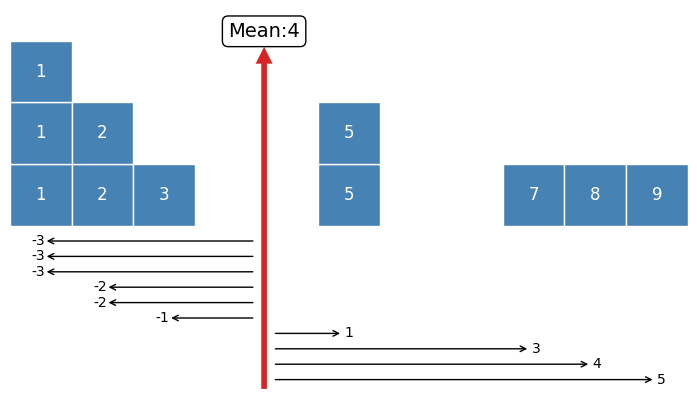

In [130]:
data_arr = np.asarray(data_1)
counts, bin_edges = np.histogram(data_arr, bins=11)
bin_width = bin_edges[1] - bin_edges[0]

# Create matplotlib figure
fig, ax = plt.subplots(figsize=(10, 5))

n_bins = len(bin_edges) - 1

for i in range(n_bins):
    left, right = bin_edges[i], bin_edges[i + 1]
    if i < n_bins - 1:
        in_bin = data_arr[(data_arr >= left) & (data_arr < right)]
    else:
        in_bin = data_arr[(data_arr >= left) & (data_arr <= right)]
    in_bin_sorted = np.sort(in_bin)
    
    # Create squares for each observations
    for j, val in enumerate(in_bin_sorted):
        square = patches.Rectangle(
            (left, j), bin_width, 1,
            facecolor="steelblue", edgecolor="white"
        )
        ax.add_patch(square)
        # Add number text to center of each square
        ax.text(
            left + bin_width / 2, j + 0.5, f"{val:g}",
            ha="center", va="center", color="white", fontsize=12
        )

# Set x-axis limits
ax.set_xlim(bin_edges[0], bin_edges[-1])

# Set y-axis limits with extra room for the "Mean" label
ax.set_ylim(-2.75, counts.max() + 0.5)

# Add deviation values
for text, x_pos, y_pos in deviation_labels:
    ax.annotate(
        text,
        xy=(x_pos, y_pos),
        ha="center",
        va="center",
        fontsize=10
    )

# Add deviation arrows
for target_x, arrows in deviation_arrow_groups:
    for x_start, y in arrows:
        ax.annotate(
            "",
            xy=(target_x, y),
            xytext=(x_start, y),
            arrowprops=dict(arrowstyle="<-", lw=1, color="black")
        )

# Add mean annotation
ax.annotate(
    "Mean:4",
    xy=(4,3),
    ha="center",
    va="bottom",
    fontsize=14,
    bbox=dict(facecolor="white",
             edgecolor="black",
             boxstyle="round")
           )

# Add vertical arrow at Mean below 
ax.annotate(
    '',
    xy=(4,2.9),
    xytext=(4,-2.65),
    arrowprops=dict(color="#d72323",lw=0.1),
    zorder=2
)

# Set aspect ratio to bin width
ax.set_aspect(bin_width)

# Despine the plot
sns.despine(left=True, bottom=True)

# Hide x and y ticks
ax.set_yticks([])
ax.set_xticks([])

plt.show()

## Figure 6.
The average moving range is the average (mean) difference between successive values in a dataset.

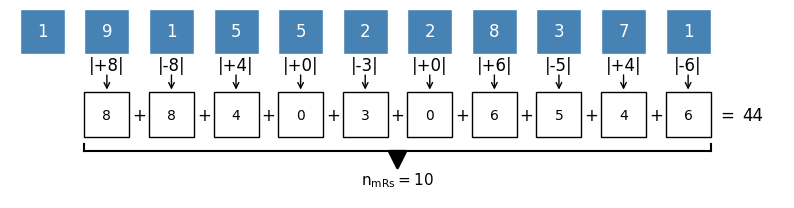

In [147]:
data_arr = np.asarray(data_1)

# Square size and spacing
square_width = 0.8
slot_width = 1.15

# Vertical positions
label_y = -0.25
diff_square_y = -1.35

# Create matplotlib figure
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the original measurements
for i, value in enumerate(data_arr):

    x = i * slot_width + (slot_width - square_width) / 2

    # Create square for each measurement
    ax.add_patch(
        patches.Rectangle(
            (x, 0),
            square_width,
            1,
            facecolor="steelblue",
            edgecolor="white"
        )
    )

    # Add the value for each measurement
    ax.text(
        x + square_width / 2,
        0.5,
        f"{value:g}",
        ha="center",
        va="center",
        color="white",
        fontsize=12
    )

# Plot the moving ranges
diffs = np.abs(np.diff(data_arr))

for i, diff in enumerate(diffs):

    # Position between two measurements
    x = (i + 1) * slot_width + slot_width / 2

    # Add the moving range squares
    ax.add_patch(
        patches.Rectangle(
            (x - square_width / 2, diff_square_y - 0.5),
            square_width,
            1,
            facecolor="white",
            edgecolor="black"
        )
    )

    # Add absolute difference notation
    raw_diff = data_arr[i + 1] - data_arr[i]

    ax.text(
        x,
        label_y,
        f"|{raw_diff:+g}|",
        ha="center",
        va="center",
        fontsize=12
    )

    # Arrow from absolute difference to moving-range square
    ax.annotate(
        "",
        xy=(x, -0.85),
        xytext=(x, label_y - 0.15),
        arrowprops=dict(
            arrowstyle="->",
            color="black",
            lw=1
        )
    )

    # Add moving range value text
    ax.text(
        x,
        diff_square_y,
        f"{diff:g}",
        ha="center",
        va="center",
        fontsize=10,
        zorder=3
    )

    # Add plus sign between moving ranges
    if i > 0:
        previous_x = i * slot_width + slot_width / 2
        plus_x = (previous_x + x) / 2

        ax.text(
            plus_x,
            diff_square_y,
            "+",
            ha="center",
            va="center",
            fontsize=12,
            zorder=3
        )


# Add sum of ranges annotation
last_x = (len(data_arr) - 1) * slot_width + slot_width / 2

x_equals = last_x + slot_width * 0.6
x_sum = x_equals + slot_width * 0.4

ax.text(
    x_equals,
    diff_square_y,
    "=",
    ha="center",
    va="center",
    fontsize=12
)

ax.text(
    x_sum,
    diff_square_y,
    f"{diffs.sum():g}",
    ha="center",
    va="center",
    fontsize=12
)


# Bracket the moving ranges
first_box_left = slot_width + slot_width / 2 - square_width / 2
last_box_right = (
    (len(data_arr) - 1) * slot_width
    + slot_width / 2
    + square_width / 2
)

bracket_y = diff_square_y - 0.8

ax.plot(
    [first_box_left, last_box_right],
    [bracket_y, bracket_y],
    color="black",
    lw=1.5
)

ax.plot(
    [first_box_left, first_box_left],
    [bracket_y, bracket_y + 0.15],
    color="black",
    lw=1.5
)

ax.plot(
    [last_box_right, last_box_right],
    [bracket_y, bracket_y + 0.15],
    color="black",
    lw=1.5
)


# Add n_mRs label
x_mid = (first_box_left + last_box_right) / 2
n_moving_ranges = len(diffs)

ax.annotate(
    "",
    xy=(x_mid, bracket_y - 0.38),
    xytext=(x_mid, bracket_y-0.1),
    arrowprops=dict(
#         arrowstyle="-|>",
        color="black",
        lw=2
    )
)

ax.text(
    x_mid,
    bracket_y - 0.65,
    rf"$\mathrm{{n_{{mRs}} = {n_moving_ranges}}}$",
    ha="center",
    va="center",
    fontsize=11
)


# Set x and y limits
ax.set_xlim(0, x_sum + slot_width * 0.5)
ax.set_ylim(-3.2, 1)

# Set aspect ratio
ax.set_aspect(square_width)

# Remove x and y ticks
ax.set_yticks([])
ax.set_xticks([])

# Despine the plot
sns.despine(left=True, bottom=True)

plt.show()

## Figure 7.
Process limits calculated using the standard deviation are less sensitive than their within-subgroup measure of dispersion counterparts.

In [11]:
cellex_url = r"https://raw.githubusercontent.com/jimlehner/The-Math-Matters/refs/heads/main/measures-of-dispersion/data/cellex-cell-voltage.csv"

# Get data function
def get_data(dataset_url) -> pd.DataFrame:
    return pd.read_csv(dataset_url)

# Get the data
cellex_df = get_data(cellex_url)

cellex_df.head()

,Supplier,Sample,Cell Voltage (mV)
0,Cellex,1,642.768
1,Cellex,2,657.319
2,Cellex,3,664.052
3,Cellex,4,658.694
4,Cellex,5,642.644


In [12]:
voltage = cellex_df["Cell Voltage (mV)"]
voltage_mRs = voltage.diff().abs()
voltage_mRs.head()

0       NaN
1    14.551
2     6.733
3     5.358
4    16.050
Name: Cell Voltage (mV), dtype: float64

In [14]:
# Calculate numerical summaries
mean = round(voltage.mean(), 2)
ave_mR = round(voltage_mRs.mean(), 2)
stdev = round(voltage.std(), 2)
stdev

10.38

In [15]:
# Calculate two types of process limits
UPL = round(mean + (2.660*ave_mR), 2)
LPL = round(mean - (2.660*ave_mR), 2)
URL = round(3.268*ave_mR, 2)

UPL_sigma = round(mean + (3*stdev), 2)
LPL_sigma = round(mean - (3*stdev), 2)

In [72]:
# Values for each subplot
methods = [
    {
        "title": "Mean ± (2.660 • $\mathrm{\overline{mR}}$)",
        "location": mean,
        "upper": UPL,
        "central": mean,
        "lower": LPL,
        "label": "Mean",
        "annotation": "Assignable cause\ndetected",
    },
    {
        "title": r"Mean ± (3 • s)",
        "location": mean,
        "upper": UPL_sigma,
        "lower": LPL_sigma,
        "label": "Mean",
        "annotation": "Assignable cause\nmissed"
    }
]

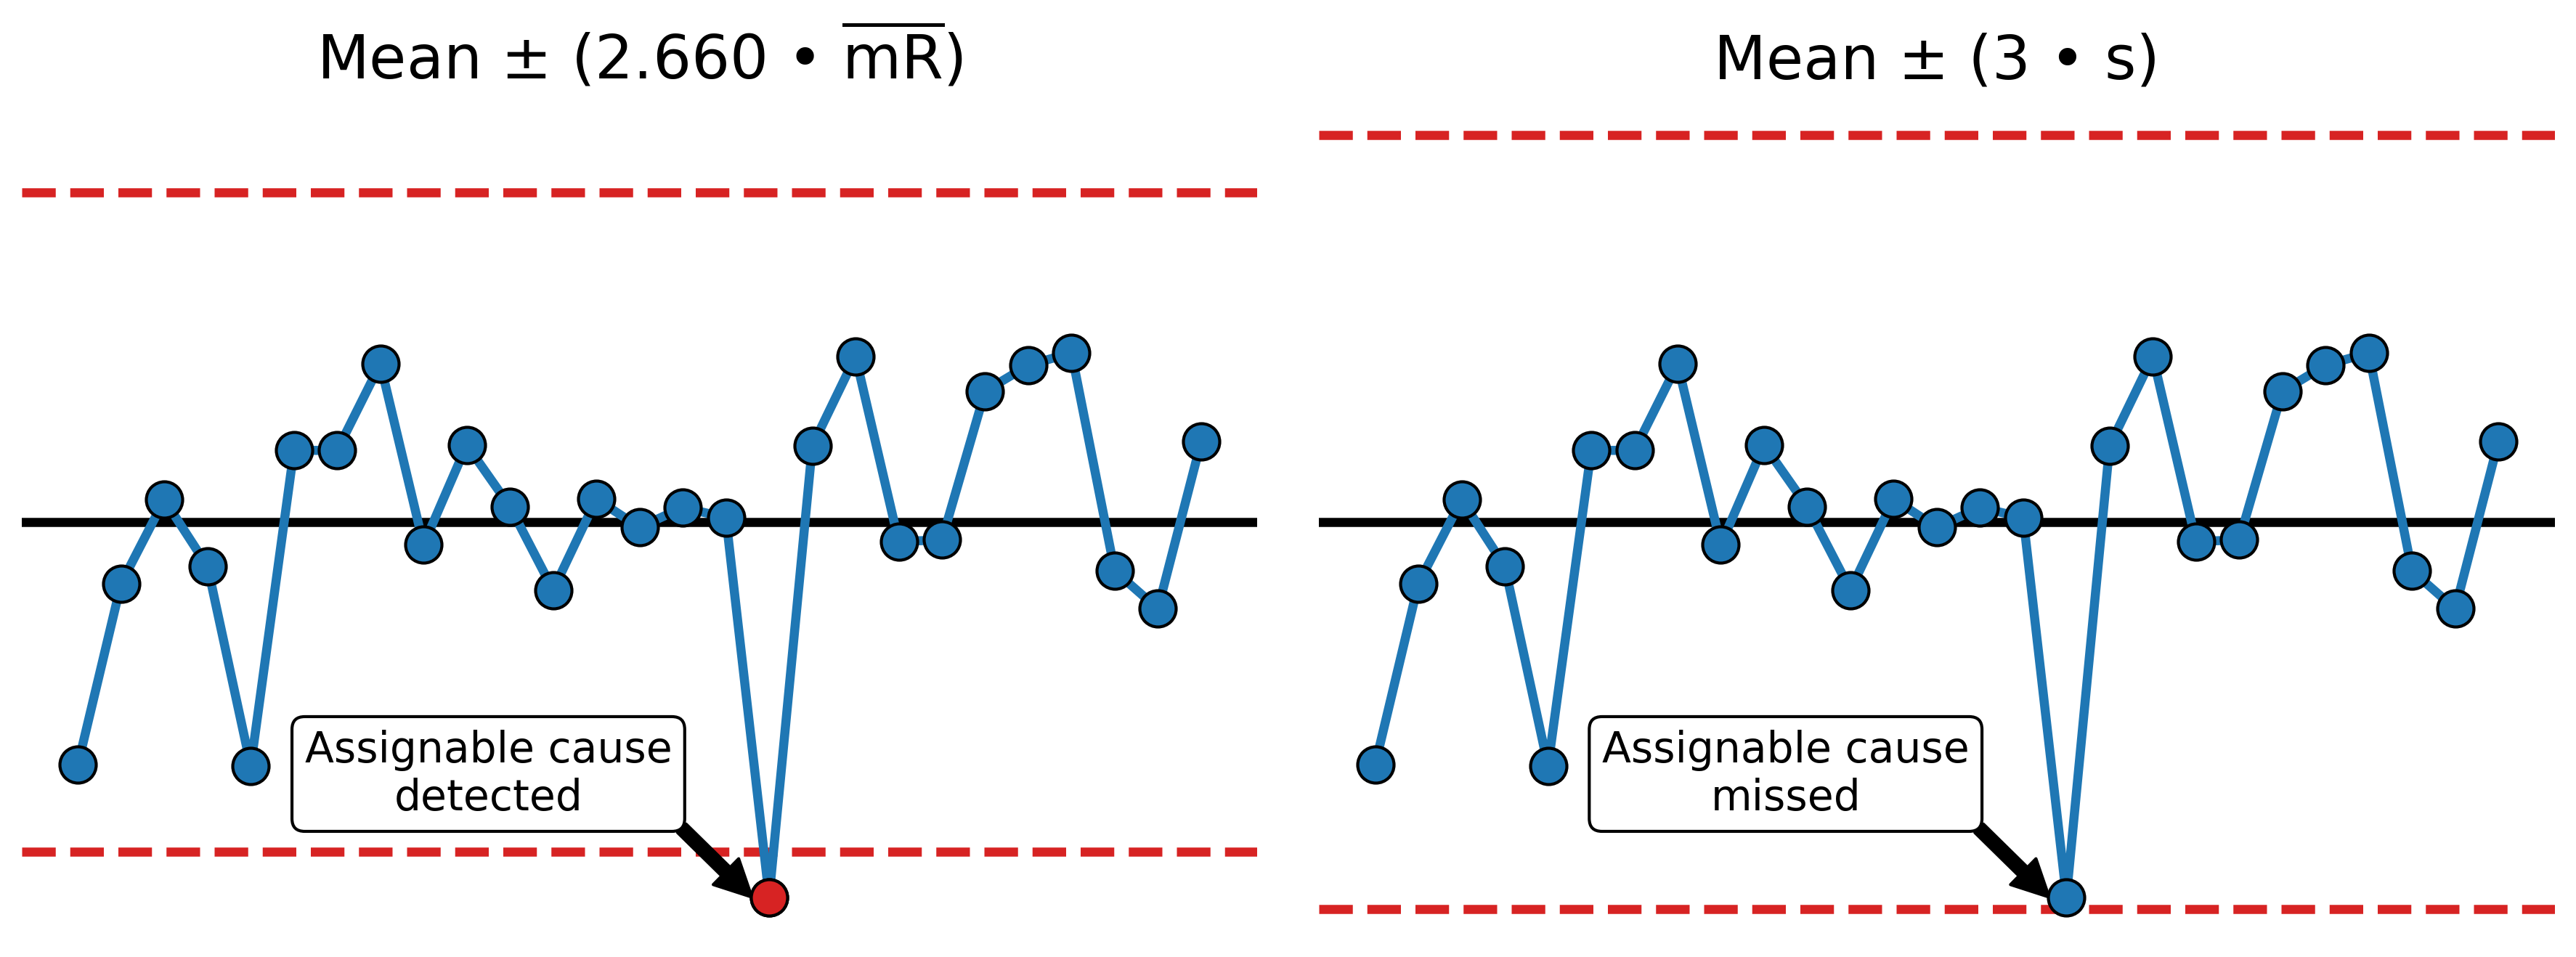

In [73]:
fig, axes = plt.subplots(nrows=1, 
                         ncols=2, 
                         figsize=(15,5), 
                         sharey=True, 
                         dpi=300)

# Adjust whitespace between subplots
plt.subplots_adjust(wspace=0.05)

# Plot the data and limits
for ax, method in zip(axes, methods):
    ax.plot(
        voltage,
        marker="o",
        markersize=12,
        markeredgecolor='black',
        linewidth=3, 
        zorder=4
    )
    
    # Highlight values less than the lower process limits (LPLs)
    below_lpl = voltage < method["lower"]
    
    # Highlight values less than the LPL
    ax.plot(
        voltage[below_lpl],
        marker="o",
        markersize=12,
        markeredgecolor="black",
        markerfacecolor="#d72323",
        linestyle="none",
        zorder=5
    )
    
    ax.axhline(
        method["location"],
        linestyle="-",
        color="black",
        linewidth=3
    )
    
    ax.annotate(
        method["annotation"],
        xy=(15.6,632.103),
        xytext=(9.5,642),
        ha="center",
        va="center",
        fontsize=14,
        bbox=dict(facecolor="white",
                  edgecolor="black",
                  boxstyle="round"
                 ),
        arrowprops=dict(facecolor="black")
    )
    
    # Add the process limits
    for limit in ["upper", "lower"]:
        ax.axhline(
            method[limit],
            linestyle="--",
            color="#d72323",
            linewidth=3,
            label="Process limit" if limit == "upper" else None
        )
    
    # Add the titles
    ax.set_title(
        method["title"], 
        fontsize=20)
    
    ax.set_xticks([])
    ax.set_yticks([])

sns.despine(left=True, bottom=True)
        
plt.show()